In [1]:
# Librerías
import numpy as np
import os
from PIL import Image

In [2]:
# Establecer ruta correspondiente
path = "17flowers"

En el siguiente enlace encontrará la base de datos y el tipo de flor de cada categoría

[Categorías](https://www.robots.ox.ac.uk/~vgg/data/flowers/17/index.html)

In [3]:
# Elegir las clases correspondientes, enteros entre 0 y 16
classes = [3, 5, 7, 9, 14]
tamano_imagen = 64

In [4]:
# Extraer las imágenes correspondientes a las clases seleccionadas
n_per_class = 80
images = []
images_resized = []
labels = []
target_size = (tamano_imagen, tamano_imagen)
for c in classes:
    start = c * n_per_class
    end = (c + 1) * n_per_class
    for i in range(start, end):
        name_file = f"{path}\\jpg\\image_{i+1:04d}.jpg"
        img = Image.open(name_file)
        images.append(img)
        img_resized = img.convert("RGB").resize(target_size)
        images_resized.append(img_resized)
        labels.append(c)

In [5]:
# mappear las etiquetas a valores entre 0 y len(classes)-1
label_map = {original: new for new, original in enumerate(classes)} 
labels = [label_map[label] for label in labels]
labels = np.array(labels)

In [6]:
label_map

{3: 0, 5: 1, 7: 2, 9: 3, 14: 4}

In [7]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [8]:
print(f"Cada imagen tiene {tamano_imagen}x{tamano_imagen} pixeles y 3 canales (RGB)")
print(f"Total de atributos por imagen: {tamano_imagen * tamano_imagen * 3}")

Cada imagen tiene 64x64 pixeles y 3 canales (RGB)
Total de atributos por imagen: 12288


## **Ejemplo de imagenes**

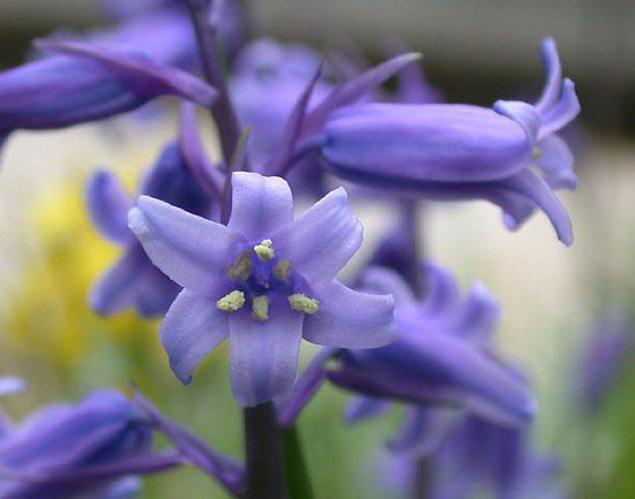

In [9]:
# Tamaño original
images[0]

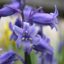

In [10]:
# Compresión y homogeneización de la imagen
images_resized[0]

## **Poner bonitos los datos**

In [11]:
# Convertir a vector de dimensión 128*128*3=49152 o 64*64*3=12288 y agregar un 1 al final
X = [np.array(img).flatten() for img in images_resized]
X = np.array(X)
X = np.hstack([X, np.ones((X.shape[0], 1))])
X

array([[102.,  99.,  93., ..., 105.,  23.,   1.],
       [151., 174., 148., ..., 136.,  70.,   1.],
       [255., 255., 255., ..., 190., 167.,   1.],
       ...,
       [  3.,   3.,   1., ...,  19.,   8.,   1.],
       [ 15.,  30.,   7., ...,  26.,  10.,   1.],
       [ 54.,  94.,  67., ...,  98.,  44.,   1.]], shape=(400, 12289))

In [12]:
def crearCeros(X):
    """
    Crear un vector de ceros de tamaño igual al número de atributos de X
    """
    zeros = np.zeros((X.shape[1], 1))
    zeros = zeros.flatten()
    return zeros

In [13]:
zeros = crearCeros(X)
zeros.shape

(12289,)

In [14]:
clasificaciones = len(classes)
imagenes = X.shape[0]
dimension = X.shape[1]
filas = clasificaciones - 1
columnas = dimension * (clasificaciones-1) 
pixelesxcanal = dimension - 1
imagesize = int(np.sqrt(int((dimension-1)/3)))

print(f"Clasificaciones: {clasificaciones}")
print(f"Imágenes: \t {imagenes}")
print(f"Dimensión: \t {dimension} \t (Dimensión del vector de cada imagen incluyendo el 1 que absorbe el sesgo)")
print(f"Pixeles x Canal: {pixelesxcanal}")
print(f"Imagen: \t {imagesize}x{imagesize}x3")
print(f"Filas: \t \t {filas} \t (Filas de la construcción de Kessler)")
print(f"Columnas: \t {columnas} \t (Columnas para la construcción de Kessler sin incluir la columna del vector correcto)")
print(f"Dim x Clasif: \t {dimension*clasificaciones} \t (Columnas de la construcción de Kessler)")

Clasificaciones: 5
Imágenes: 	 400
Dimensión: 	 12289 	 (Dimensión del vector de cada imagen incluyendo el 1 que absorbe el sesgo)
Pixeles x Canal: 12288
Imagen: 	 64x64x3
Filas: 	 	 4 	 (Filas de la construcción de Kessler)
Columnas: 	 49156 	 (Columnas para la construcción de Kessler sin incluir la columna del vector correcto)
Dim x Clasif: 	 61445 	 (Columnas de la construcción de Kessler)


## **Para una imagen**

In [15]:
def crearVectorCorrecto(nimagen, filas):
    """
    El vector correcto es simplemente el dato repetido 'filas' veces
    """
    return np.tile(X[nimagen], (filas, 1))

In [16]:
def crearColumnas(nimagen, filas, clasificaciones, zeros):
    """
    Crear las otras 'clasificaciones-1' columnas incorrectas
    """
    columnas = []
    for i in range(clasificaciones - 1):
        nuevaColumna = np.tile(zeros, (filas, 1))
        nuevaColumna[i, :] = -X[nimagen]
        columnas.append(nuevaColumna)
    return columnas

In [17]:
def crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k):
    """
    Crear la matriz de la construcción de Kessler para la clase k para una observación dada juntando la columna correcta y las columnas incorrectas
    """
    cols = []
    for j in range(clasificaciones):
        if k == j:
            cols.append(vectorCorrecto)
        else:
            cols.append(columnas[j if j < k else j-1])
    return np.concatenate(cols, axis=1)

In [18]:
nimagen = 0

In [19]:
vectorCorrecto = crearVectorCorrecto(nimagen, filas)
vectorCorrecto

array([[102.,  99.,  93., ..., 105.,  23.,   1.],
       [102.,  99.,  93., ..., 105.,  23.,   1.],
       [102.,  99.,  93., ..., 105.,  23.,   1.],
       [102.,  99.,  93., ..., 105.,  23.,   1.]], shape=(4, 12289))

In [20]:
columnas = crearColumnas(nimagen, filas, clasificaciones, zeros)
columnas[0]

array([[-102.,  -99.,  -93., ..., -105.,  -23.,   -1.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]], shape=(4, 12289))

In [21]:
columnas[1]

array([[   0.,    0.,    0., ...,    0.,    0.,    0.],
       [-102.,  -99.,  -93., ..., -105.,  -23.,   -1.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]], shape=(4, 12289))

In [22]:
k = 4
matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
matrizClaseK

array([[-102.,  -99.,  -93., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.]], shape=(4, 61445))

In [23]:
k = 3
matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
matrizClaseK

array([[-102.,  -99.,  -93., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ..., -105.,  -23.,   -1.]], shape=(4, 61445))

In [24]:
k = 0
matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
matrizClaseK

array([[ 102.,   99.,   93., ...,    0.,    0.,    0.],
       [ 102.,   99.,   93., ...,    0.,    0.,    0.],
       [ 102.,   99.,   93., ...,    0.,    0.,    0.],
       [ 102.,   99.,   93., ..., -105.,  -23.,   -1.]], shape=(4, 61445))

# **Para n imágenes**

In [25]:
def crearMatrizKessler(imagenes, filas, clasificaciones, labels, zeros):
    """
    Crear la matriz de Kessler para todas las imágenes
    """
    nimagen = 0
    # Crear el vector correcto para la imagen
    vectorCorrecto = crearVectorCorrecto(nimagen, filas)
    # Crear las columnas para la imagen
    columnas = crearColumnas(nimagen, filas, clasificaciones, zeros)
    # Conseguir la etiqueta k de la imagen
    k = labels[nimagen]
    # Crear la matriz de la clase k
    matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
    # Si es la primera imagen, inicializar la matrizKessler
    matrizKessler = matrizClaseK

    # Para la imagen 1 hasta la última
    for nimagen in range(1, imagenes):
        # Crear el vector correcto para la imagen
        vectorCorrecto = crearVectorCorrecto(nimagen, filas)
        # Crear las columnas para la imagen
        columnas = crearColumnas(nimagen, filas, clasificaciones, zeros)
        # Conseguir la etiqueta k de la imagen
        k = labels[nimagen]
        # Crear la matriz de la clase k
        matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
        # Agregar la matriz de la clase k a la matriz grande de Kessler
        # Si no es la primera imagen, apilar la matriz de la clase k
        matrizKessler = np.vstack([matrizKessler, matrizClaseK])

    return matrizKessler

In [41]:
imagenes = 80*3
matrizKessler = crearMatrizKessler(imagenes, filas, clasificaciones, labels, zeros)
matrizKessler

array([[102.,  99.,  93., ...,   0.,   0.,   0.],
       [102.,  99.,  93., ...,   0.,   0.,   0.],
       [102.,  99.,  93., ...,   0.,   0.,   0.],
       ...,
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ..., -87., -69.,  -1.]], shape=(960, 61445))

In [42]:
print(f"Deberia haber {filas * imagenes} filas en la matriz de Kessler")

Deberia haber 960 filas en la matriz de Kessler


## **Perceptron para la Matriz de Kessler**

In [40]:
# from sklearn.linear_model import Perceptron as SklearnPerceptron

# # Crear todos los targets con 1
# targets = np.ones((matrizKessler.shape[0],))
# targets.shape

# sklearn_perceptron = SklearnPerceptron(max_iter=10)
# sklearn_perceptron.fit(matrizKessler, targets)

In [31]:
def perceptron_one_class(V, epochs=1000, lr=1.0):
    w = np.zeros(V.shape[1], dtype=float)
    for _ in range(epochs):
        err = 0
        for v in V:
            if w @ v <= 0:
                w += lr * v
                err += 1
        if err == 0:
            break
    return w

In [43]:
M = clasificaciones 
V = matrizKessler        # matriz de Kessler
w = perceptron_one_class(V, epochs=100, lr=1.0)
blk = V.shape[1] // M     # d (+1 si metiste bias por bloque)
if w.size != M * blk:
	raise ValueError(f"Cannot reshape array of size {w.size} into shape ({M}, {blk}). Check the dimensions.")
W = w[:M * blk].reshape(M, blk)  # filas: w_i

In [44]:
# Utiliza los pesos y sesgos anteriores para identificar que imágenes son clasificadas correctamente.
correctas = 0
for i in range(imagenes):
    x = X[i]
    scores = W @ x
    pred = np.argmax(scores)
    if pred == labels[i]:
        correctas += 1
print(f"Se clasificaron correctamente {correctas} de {imagenes} imágenes")

Se clasificaron correctamente 184 de 240 imágenes


In [45]:
# Calcula la exactitud del modelo.
exactitud = correctas / imagenes
print(f"Exactitud del modelo: {exactitud*100:.2f}%")

Exactitud del modelo: 76.67%
